# =========================================================
# Simple U-Net for Image Segmentation (Colab-ready)
# Dataset: MNIST Digits (toy segmentation example)
# Author: Alan (FYP Medical Image Segmentation)
# =========================================================

# ---------------------------------------------------------
# 1. Install & Import Dependencies
# ---------------------------------------------------------

In [ ]:
!pip install torch torchvision matplotlib --quiet


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 2. Create a Toy Segmentation Dataset
# ---------------------------------------------------------

In [3]:
class MNISTSegmentation(Dataset):
    """
    Converts MNIST digits into segmentation masks.
    Task: segment out the digit from the background.
    """
    def __init__(self, train=True):
        self.data = torchvision.datasets.MNIST(
            root="./data", train=train, download=True, transform=T.ToTensor()
        )

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image, label = self.data[idx]

        # Make segmentation mask (digit=1, background=0)
        mask = (image > 0).float()

        return image, mask

# ---------------------------------------------------------
# 3. Simple U-Net Architecture
# ---------------------------------------------------------


In [4]:
class DoubleConv(nn.Module):
    """(Conv2d => ReLU => Conv2d => ReLU)"""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        bottleneck = self.bottleneck(self.pool2(enc2))

        dec1 = self.up1(bottleneck)
        dec1 = torch.cat((dec1, enc2), dim=1)
        dec1 = self.dec1(dec1)

        dec2 = self.up2(dec1)
        dec2 = torch.cat((dec2, enc1), dim=1)
        dec2 = self.dec2(dec2)

        return torch.sigmoid(self.final_conv(dec2))

# ---------------------------------------------------------
# 4. Training Utilities
# ---------------------------------------------------------

In [5]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)

# ---------------------------------------------------------
# 5. Visualization Utility
# ---------------------------------------------------------

In [6]:
def visualize(model, dataset, device, num_samples=5):
    model.eval()
    fig, axes = plt.subplots(num_samples, 3, figsize=(8, num_samples * 3))

    for i in range(num_samples):
        image, mask = dataset[i]
        image = image.unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(image).cpu().squeeze().numpy()

        axes[i, 0].imshow(image.cpu().squeeze(), cmap="gray")
        axes[i, 0].set_title("Input Image")
        axes[i, 1].imshow(mask.squeeze(), cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 2].imshow(pred > 0.5, cmap="gray")
        axes[i, 2].set_title("Prediction")

        for j in range(3):
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# 6. Main Training Loop
# ---------------------------------------------------------

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.70MB/s]


Epoch 1, Loss: 0.0121
Epoch 2, Loss: 0.0010
Epoch 3, Loss: 0.0012
Epoch 4, Loss: 0.0004
Epoch 5, Loss: 0.0002


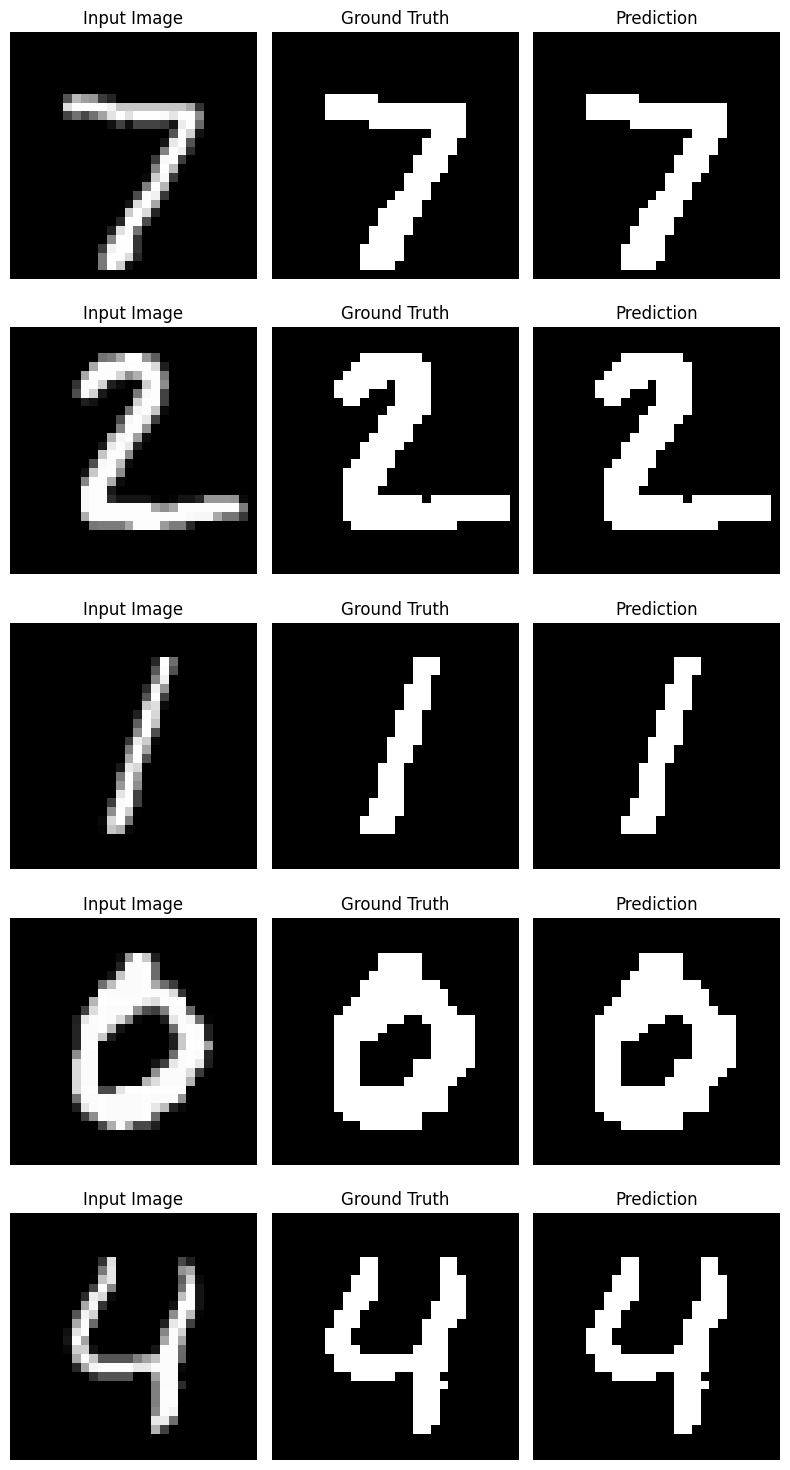

In [7]:
def main():
    # Device setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Dataset & Dataloader
    train_dataset = MNISTSegmentation(train=True)
    test_dataset = MNISTSegmentation(train=False)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # Model, Loss, Optimizer
    model = UNet().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Training (5 epochs for demo)
    for epoch in range(5):
        loss = train(model, train_loader, optimizer, criterion, device)
        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

    # Visualization
    visualize(model, test_dataset, device)

if __name__ == "__main__":
    main()